# *Aufgabe: Lineare Methoden*

0. Importieren Sie alle die nötigen Bibliotheken.

In [45]:
# Zum Beispiel zur Darstellung
import matplotlib.pyplot as plt

# Für den Umgang mit Arrays
import numpy as np
import pandas as pd
import os

from scipy import stats

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

import math

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from matplotlib import cm
# Importieren sie benötigte Funktionen für die Modelle und statistische Auswertung

### Aufgabe 1. Lineare Regression per Hand
Implementieren Sie die Lineare Regression per Hand. Versuchen Sie händisch so eine Kombination von w (Gewicht) und b (Bias) zu finden, dass der Fehler (MSE/SSE/RMSE) minimal wird. Visualisieren Sie das modell für unterschiedliche w’s und b’s. Nutzen Sie dafür folgende Daten:

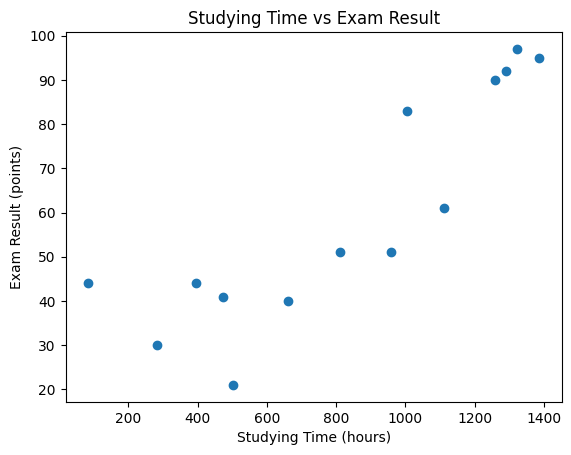

In [4]:
# Vorgegebene Daten aus der Aufgabe
studying = np.array(
    [84, 1323, 282, 957, 1386, 810, 396, 474, 501, 660, 1260, 1005, 1110, 1290]
)
result = np.array([44, 97, 30, 51, 95, 51, 44, 41, 21, 40, 90, 83, 61, 92])

# Visualisieren sie die Daten um ein Gefühl für die Verteilung zu bekommen

plt.scatter(studying, result)
plt.xlabel("Studying Time (hours)")
plt.ylabel("Exam Result (points)")
plt.title("Studying Time vs Exam Result")
#plt.grid()
plt.show()

Definieren Sie Vektoren mit Gewichten und Bias Werten und berechnen Sie die lineare Regression sowie den Fehler. Visualisieren Sie Ihr Ergebnis.

In [ ]:
# Definieren Sie Vektoren mit Gewichten und Bias Werten und berechnen Sie die lineare Regression sowie den Fehler
# Die Werte der Gewichte und Biases können zufällig gewählt werden

# Die Gewichte und der Bias ergeben mit den Eingabewerten eine Funktion für die Vorhersage

# Der Fehler berechnet sich aus der Vorhersage und den Zielwerten

# Visualisieren Sie Ihr Ergebnis als Regressionsgeraden für alle Kombinationen

### Aufgabe 2. Polynomiale Regression

1. Implementieren Sie ein Polynomiales Modell für Regression für den Polynomgrad 1 bis 7. Trainieren Sie dafür sklearn Modelle, die für den studying Vektor die Prädiktion von result zurückliefert (die Daten aus der Aufgabe 1). Vergleichen Sie den Fehler für unterschiedliche Polynomgrade. Visualisieren Sie die Modelle. 

Mean Squared Error (MSE) für polynomiale Modelle:
Polynom Grad 1: MSE = 152.6751
Polynom Grad 2: MSE = 76.3993
Polynom Grad 3: MSE = 71.7595
Polynom Grad 4: MSE = 71.4792
Polynom Grad 5: MSE = 71.3852
Polynom Grad 6: MSE = 73.6934
Polynom Grad 7: MSE = 76.2904


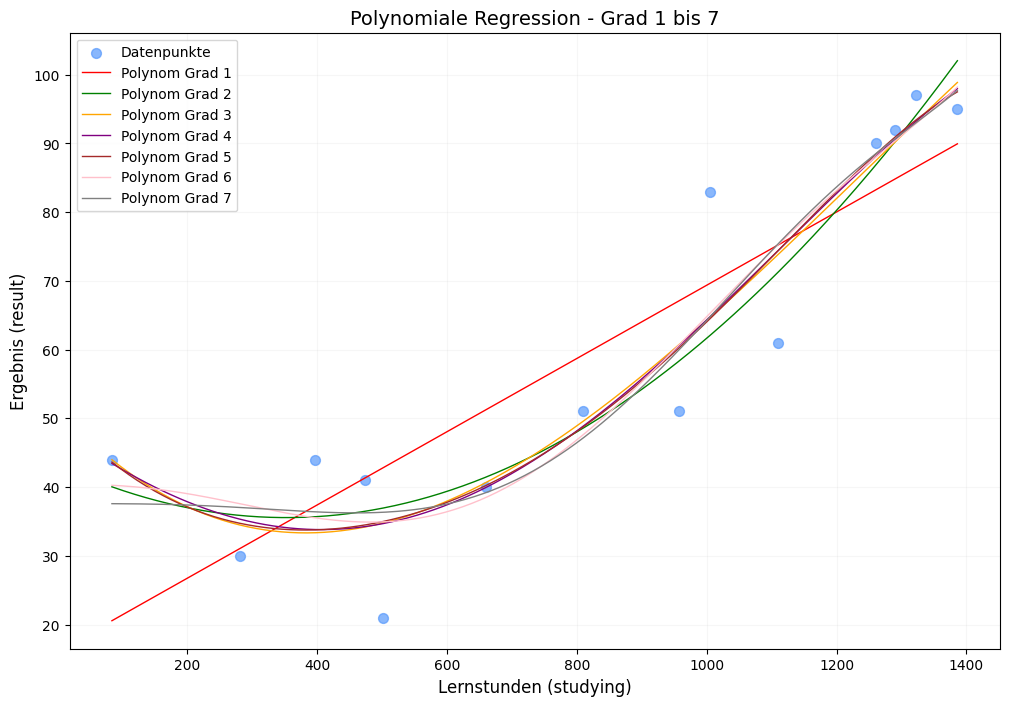

In [53]:
studying = np.array(
    [84, 1323, 282, 957, 1386, 810, 396, 474, 501, 660, 1260, 1005, 1110, 1290]
)
result = np.array([44, 97, 30, 51, 95, 51, 44, 41, 21, 40, 90, 83, 61, 92])

models = {}  # Dictionary zum Speichern der Modelle
poly_features = {}  # Dictionary zum Speichern der PolynomialFeatures

for degree in range(1, 8):
    poly = PolynomialFeatures(degree)
    x_poly = poly.fit_transform(studying.reshape(-1, 1))
    model = LinearRegression()
    model.fit(x_poly, result)

    models[degree] = model
    poly_features[degree] = poly



# Berechne den MSE für jedes Modell auf den Trainingsdaten
def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)

print("Mean Squared Error (MSE) für polynomiale Modelle:")
for degree in range(1, 8):
    x_poly = poly_features[degree].transform(studying.reshape(-1, 1))
    y_pred = models[degree].predict(x_poly)
    mse_value = mse(y_pred, result)
    print(f"Polynom Grad {degree}: MSE = {mse_value:.4f}")

# Visualisieren Sie die Regressionskurven
x_range = np.linspace(studying.min(), studying.max(), 300).reshape(-1, 1)

plt.figure(figsize=(12, 8))
plt.scatter(studying, result, color="#5799FC", label="Datenpunkte", s=50, alpha=0.7)

colors = ["red", "green", "orange", "purple", "brown", "pink", "gray"]

for degree in range(1, 8):
    x_poly_range = poly_features[degree].transform(x_range)
    y_pred = models[degree].predict(x_poly_range)
    plt.plot(
        x_range,
        y_pred,
        color=colors[degree - 1],
        label=f"Polynom Grad {degree}",
        linewidth=1,
    )

plt.xlabel("Lernstunden (studying)", fontsize=12)
plt.ylabel("Ergebnis (result)", fontsize=12)
plt.title("Polynomiale Regression - Grad 1 bis 7", fontsize=14)
plt.legend(loc="best")
plt.grid(True, alpha=0.1)
plt.show()

2. Binarisieren Sie nun den Result Vektor für die Logistische Regression nach Bestanden (>= 50) und Nicht Bestanden (< 50) und implementieren Sie vergleichbar zu der Aufgabe 2 eine Logistische Regression für Klassifikation. 

Wahrscheinlichkeiten:
 [2.24746272e-28 1.00000000e+00 5.76626162e-20 1.00000000e+00
 1.00000000e+00 9.99347945e-01 4.00457113e-15 8.22757578e-12
 1.15340342e-10 6.52441679e-04 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
Klassenvorhersage:
 [0 1 0 1 1 1 0 0 0 0 1 1 1 1]
Accuracy: 1.0000


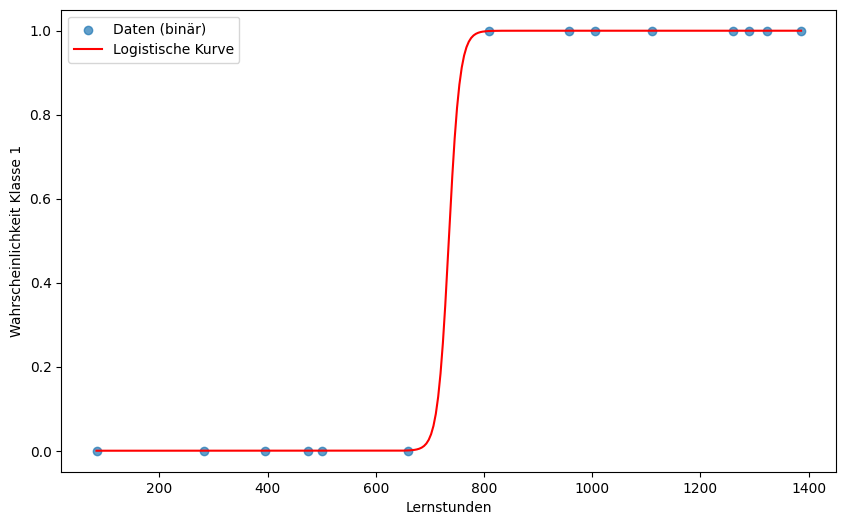

In [ ]:
# Binarisieren Sie das Ergebnis, so dass der Vektor nur noch aus 0 und 1 besteht
result_binary = np.where(result >= 50, 1, 0)
#print(result_binary)
#print(studying)

# trainiere logistische Regression
poly = PolynomialFeatures(1)  # hier Grad 1 (linear) – kann erhöht werden
x_poly = poly.fit_transform(studying.reshape(-1, 1))

logreg = LogisticRegression()
logreg.fit(x_poly, result_binary)


# Vorhersagewahrscheinlichkeiten und Klassenvorhersage
probs = logreg.predict_proba(x_poly)[:, 1]  # Wahrscheinlichkeit für Klasse 1
preds = logreg.predict(x_poly)

accuracy = np.mean(preds == result_binary)

#print("Wahrscheinlichkeiten:\n", probs)
#print("Klassenvorhersage:\n", preds)
print(f"Accuracy: {accuracy:.4f}")

# Visualisierung über Wertebereich (optional)
x_range = np.linspace(studying.min(), studying.max(), 300).reshape(-1, 1)
x_poly_range = poly.transform(x_range)
y_prob_range = logreg.predict_proba(x_poly_range)[:, 1]

plt.figure(figsize=(10, 6))
plt.scatter(studying, result_binary, label="Daten (binär)", alpha=0.7)
plt.plot(x_range, y_prob_range, color="red", label="Logistische Kurve")
plt.xlabel("Lernstunden")
plt.ylabel("Wahrscheinlichkeit Klasse 1")
plt.legend()
plt.show()

def plot_original_data(ax, x: np.ndarray, y: np.ndarray):
    ax.scatter(
        x[np.argwhere(y >= 50)].ravel(),
        y[np.argwhere(y >= 50)].ravel(),
        c="green",
        label="Bestanden",
    )
    ax.scatter(
        x[np.argwhere(y < 50)].ravel(),
        y[np.argwhere(y < 50)].ravel(),
        c="red",
        label="Nicht bestanden",
    )


# Für die logistische Regression verwenden wir sklearn statt einer eigenen Sigmoid-Klasse
